    # Transformer

## Transformer 的架构

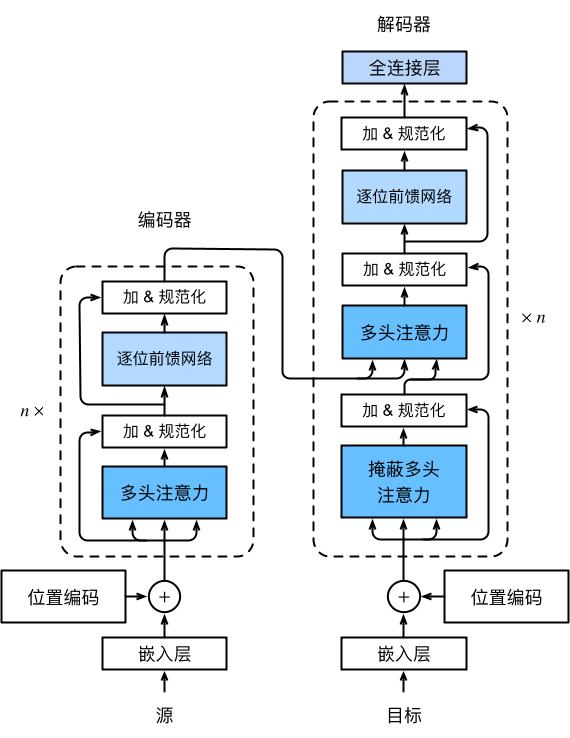

我们只考虑最简单的形式，输入一个中文句子，翻译输出一个英文句子

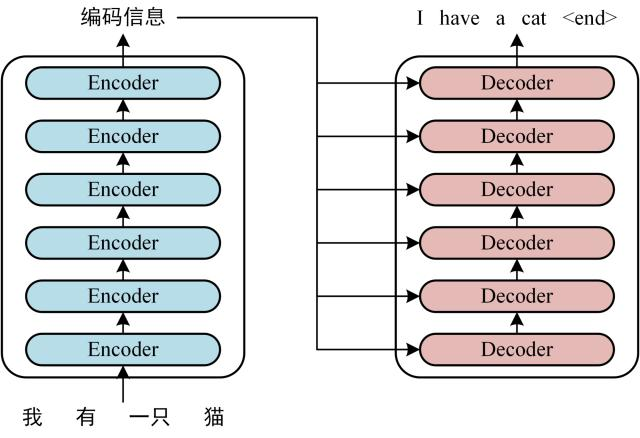

第一步：提取输入句子每一个单词的表示向量 $X$，$X$ 由单词本身的 Embedding 和单词位置的 Embedding 相加都得到。

第二步：将得到的单词表示向量拼接成矩阵后传入 Encoder，得到含有句子中所有单词的**编码信息矩阵** $C$。$X$ 和 $C$ 都是 $n\times d$ 的矩阵

第三步：将 Encoder 得到的 **编码信息矩阵** 传递到 Decoder 中。Decoder 会一次根据当前翻译过的单词 $1 \sim i$ 预测翻译下一个单词 $i+1$ 。在预测过程中会通过 **Mask（掩盖）** 操作来遮盖住之后单词的信息。


## Transformer 的输入

## 词嵌入层

单词本身的 Embeddin 可通过 Word2ver，Glove 等算法与训练得到。
```python
self.embedding = nn.Embedding(vocabulary, dim)
```
这行代码将离散的 ID 索引转换为连续的向量表示，输入形状为 $(sequence_length)$ 的整数张量，返回形状为 $(sequence_length, dim)$ 的浮点张量，其中 $dim$ 是特征维度

| 参数       | 含义     | 示例值 | 说明                              |
| ---------- | -------- | ------ | --------------------------------- |
| vocabulary | 词表大小 | 10000  | 表示模型能处理的不同单词/符号总数 |
| dim        | 嵌入维度 | 512    | 每个单词被表示成的向量长度        |

然后我们可以用整数索引去查找单词转换为的向量

词嵌入使得相似的单词由相似的向量表示，并且可降维使得空间上较 one-hot 编码更加有优势，同时训练过程中这些向量可调整自己更好表示语义关系

## 位置 Embedding

这是 Transformer 的关键创新之一，解决了传统 RNN 的顺序处理问题。使模型可以理解序列中元素的顺序关系。

| 方法      | 优点             | 缺点               |
| --------- | ---------------- | ------------------ |
| $sin/cos$ | 泛化性好         | 不够灵活，较为固定 |
| 可学习    | 适应特定任务     | 长度受限，需要训练 |
| 相对位置  | 直接建模相对距离 | 实现复杂           |

- 早期层效果：帮助模型建立位置感知
- 后期层效果：位置信息被融合到语义之中
-
### 正余弦位置编码
计算公式：

$$
P_{pos,2i} = \sin (\frac{1}{10000^{\frac{2i}{d}}}\cdot pos)
$$
$$
P_{pos,2i+1} = \cos (\frac{1}{10000^{\frac{2i}{d}}}\cdot pos)
$$

正余弦编码的周期和嵌入维度相关。在低维度周期短，可以区分相邻位置；在高维度周期长，能捕捉长距离的位置关系。
其中 10000 的经验性的参数，用于频率岁嵌入维度由高到低平滑递减，保证常见序列长度范围内都能有效区分不同位置冰捕捉不同尺度位置关系。

实现上计算 $10000^{\frac{2i}{d}}$ 可能出现精度问题，需要转化为指数计算

In [22]:
import torch
from typing import Optional
from torch import nn
from torch import Tensor

class PositionalEncoding(nn.Module):
    def __init__(self, dim_embed:int, max_len:int, freq = 10000.0):
        super(PositionalEncoding, self).__init__()
        self.dim_embed = dim_embed
        self.max_len = max_len
        self.pe = torch.zeros(max_len, dim_embed)

        pos = torch.arange(0, dim_embed).float().unsqueeze(1)
        # pos: [max_len, 1]
        div = torch.pow(freq, torch.arange(0, dim_embed, 2).float() / dim_embed)
        # div: [ceil(dim_embed / 2)]
        self.pe[:, 0::2] = torch.sin(pos / div)
        self.pe[:, 1::2] = torch.cos(pos / (div if dim_embed % 2 == 0 else div[:-1]))

    def forward(self, x: Tensor, seq_len=None) -> Tensor:
        # x: [batch_size, len, dim_embed]
        if seq_len is None:
            seq_len = x.size(-2)
        return x + self.pe[:seq_len, :]

## 自注意力和多头注意力

Encoder 包含一个 Multi-Head Attention
Decoder 包含两个 Multi-Head Attention，其中有一个用到了 Mask

### 自注意力

自注意力彻底改变了序列建模的方式，能直接捕捉序列中任意两个元素的关系，无论它们的距离多远，这和 CNN 与 RNN 有着本质的不同

首先我们有输入矩阵 $X_{n\times d}$，其中 $n$ 为序列长度，$d$ 为特征维度。

我们通过可学习的权重矩阵生成 Q（查询），K（键值），V（值）
$$
\begin{cases}
Q = XW^Q \\
K = XW^K \\
V = XW^V
\end{cases}
$$
然后计算自注意力的输出
$$
Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_K}}) V
$$
这个公式可视为四步

1. 相似度计算：$QK^T$ 计算所有查询-键对之间的点击相似度，得到大小为 $(n,n)$ 的矩阵，表示单词之间的 attention 强度，这里的**注意力评分函数**是点积，更一般地可写为 $Attention(Q,K,V) = \sum \alpha(Q,K) V$
2. 缩放：除以$\sqrt{d_k}$ 防止点击过大导致梯度消失
3. 归一化：softmax 把相似度转换为概率分布
4. 加权求和：根据得到的注意力权重对 value 加权求和，得到最终的输出



### 多头注意力

多头注意力可增强模型的表达能力
$$
MultiHead(Q,K,V) =[head_1;head_2;...;head_h]W^O
$$
其中每个注意力头：
$$
head_1 = Attention(QW_i^Q,KW_i^K,VW_i^V)
$$
因为 $h$ 份注意力互不依赖，没有先后关系，所以适合并行同时计算

其中输出投影矩阵 $W^O \in \mathbb{R} ^ {(n\times h) \times n}$ ，将并行计算得到的 $h$ 个注意力头的输出按特征维度连接后，由可学习的先行层整合信息映射为最终输出



In [23]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dim_embed:int, num_heads:int, dropout=0.1, bias=False,
                 dim_k: Optional[int] = None, dim_v: Optional[int] = None):
        super().__init__()

        if dim_embed % num_heads != 0: raise ValueError("embed_dim must be divisible by num_heads")

        self.dim_embed = dim_embed
        self.num_heads = num_heads
        self.dim_head = dim_embed // num_heads
        self.dim_k = dim_k if dim_k is not None else dim_embed
        self.dim_v = dim_v if dim_v is not None else dim_embed

        # 线性投影层
        self.q_linear = nn.Linear(self.dim_embed, self.dim_embed, bias=bias)
        self.k_linear = nn.Linear(self.dim_k, self.dim_embed, bias=bias)
        self.v_linear = nn.Linear(self.dim_v, self.dim_embed, bias=bias)
        self.o_linear = nn.Linear(self.dim_embed, self.dim_embed, bias=bias)

        self.dropout_p = float(dropout)
        self.attn_score = torch.nn.functional.scaled_dot_product_attention

    def forward(self, q: Tensor, k: Tensor, v: Tensor, valid_len: Tensor) -> Tensor:
        # q: [batch_size, dim_q, dim_embed]
        # k: [batch_size, dim_k, dim_embed]
        # v: [batch_size, dim_v, dim_embed]
        # valid_len: 有效长度 [batch_size, ] or [batch_size, dim_q]

        # 线性投影
        q_proj = self.q_linear(q)
        k_proj = self.k_linear(k)
        v_proj = self.v_linear(v)

        q_heads = self.__transpose_qkv(q_proj)
        k_heads = self.__transpose_qkv(k_proj)
        v_heads = self.__transpose_qkv(v_proj)

        # [batch_size, ] -> [batch_size * num_heads, ]
        valid_len = torch.repeat_interleave(valid_len, repeats=self.num_heads, dim=0)

        attn_output = self.attn_score(k_heads, v_heads, q_heads, valid_len)

        output_concat = self.__transpose_output(attn_output)

        return self.o_linear(output_concat)

    def __transpose_qkv(self, x: Tensor) -> Tensor: # 可视作按特征通道分组
        # x: [B, N, D] -> (B*H, N, dim_head)
        batch_size, dim_qkv, _ = x.shape
        return (x.reshape(batch_size, dim_qkv, self.num_heads, self.dim_head) # [batch_size, dim_qkv, num_heads, dim_head]
                .permute(0, 2, 1, 3) # [batch_size, num_heads, dim_qkv, dim_head]
                .reshape(-1, dim_qkv, self.dim_head)) # [batch_size * num_heads, qkv_num, dim_head]

    def __transpose_output(self, x: Tensor) -> Tensor:
        # x: [B*H, N, dim_head] -> (B*H, N, D)
        batch_times_heads, dim_qkv, _ = x.shape
        batch_size = batch_times_heads // self.num_heads
        return (x.reshape(batch_size, self.num_heads, dim_qkv, self.dim_head) # [batch_size, num_heads, dim_qkv, dim_head]
                .permute(0, 2, 1, 3) # [batch_size, num_heads, dim_qkv, dim_head]
                .reshape(batch_size, dim_qkv, self.dim_embed)) # [batch_size, qkv_num, dim_embed]




## 自注意力和多头注意力

Encoder 包含一个 Multi-Head Attention
Decoder 包含两个 Multi-Head Attention，其中有一个用到了 Mask

### 自注意力

自注意力彻底改变了序列建模的方式，能直接捕捉序列中任意两个元素的关系，无论它们的距离多远，这和 CNN 与 RNN 有着本质的不同

首先我们有输入矩阵 $X_{n\times d}$，其中 $n$ 为序列长度，$d$ 为特征维度。

我们通过可学习的权重矩阵生成 Q（查询），K（键值），V（值）
$$
\begin{cases}
Q = XW^Q \\
K = XW^K \\
V = XW^V
\end{cases}
$$
然后计算自注意力的输出
$$
Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_K}}) V
$$
这个公式可视为四步

1. 相似度计算：$QK^T$ 计算所有查询-键对之间的点击相似度，得到大小为 $(n,n)$ 的矩阵，表示单词之间的 attention 强度，这里的**注意力评分函数**是点积，更一般地可写为 $Attention(Q,K,V) = \sum \alpha(Q,K) V$
2. 缩放：除以$\sqrt{d_k}$ 防止点击过大导致梯度消失
3. 归一化：softmax 把相似度转换为概率分布
4. 加权求和：根据得到的注意力权重对 value 加权求和，得到最终的输出



### 多头注意力

多头注意力可增强模型的表达能力
$$
MultiHead(Q,K,V) =[head_1;head_2;...;head_h]W^O
$$
其中每个注意力头：
$$
head_1 = Attention(Q_iW_i^Q,K_iW_i^K,V_iW_i^V)
$$
因为 $h$ 份注意力互不依赖，没有先后关系，所以适合并行同时计算

其中输出投影矩阵 $W^O \in \mathbb{R} ^ {(n\times h) \times n}$ ，将并行计算得到的 $h$ 个注意力头的输出按特征维度连接后，由可学习的先行层整合信息映射为最终输出



## Encoder

### Add & Norm 层

由**残差连接（Add）**和**层归一化（Layer Normalization，Norm）**两个独立的操作组成。

####  残差连接（Add）

目的：解决深层神经网普遍存在的梯度消失/爆炸问题，促进信息直接流动

操作：将子层（自注意力层或FFN）的**输入**直接加到该子层的**输出**上

![img](https://i-blog.csdnimg.cn/direct/22f8d92623294f2eaed2d1505b5de0d5.png)

好处：

- 信息不容易丢，旧信息能完整传递
- 大幅降低梯度消失的风险

### Norm: LayerNorm 层归一化

Add 之后数值会每层叠加更新，所以需要做一次归一化让每个 token 向量的尺度更可控

操作：对**单个样本**在每个**特征维度**上进行归一化

- 计算该样本在该层所有特征维度上的激活值的 **均值 $\mu$**，和 **标准差$\sigma$**

- 对所有激活值进行标准化：
  $$
  LN(y)_k = \gamma_k \frac{y_k - \mu}{\sqrt{\sigma^2 + \epsilon} }+ \beta
  $$
  其中 $\epsilon$ 是一个很小的常熟，防止除以零

  缩放参数 $\gamma$ 和 平移参数 $\beta$ 是可学习的，让模型不被限死在标准正态



### Feed Forward Network （FFN）层

FFN 层的结构非常简单，由两个全连接层和一个非线性激活函数组成
$$
FFN(x) = \sigma(xW_1+b_1 )W_2+b_2
$$
核心作用是引入非线性变换能力

FFN 对每个 token 单独并行操作



### 完整 Encoder 结构

输入: x

Multi-Head Self-Attention: attn_output = Attention(x)

Add & Norm 1: y = LayerNorm (x + attn_output)

Feed Forward Network: ffn_output = FFN(y)

Add & Norm 2: output = LayerNorm(y + ffn_output)


In [24]:
import torch
import torch.nn as nn

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0., activation=nn.ReLU()):
        super(FeedForward, self).__init__()
        self.dim = dim
        self.hidden_dim = hidden_dim
        self.activation = activation
        self.dropout = nn.Dropout(p=dropout)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)

    def forward(self, x: Tensor) -> Tensor:
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class EncoderLayer(nn.Module):
    def __init__(self, dim, dim_qk, num_heads=1, dropout=0., pre_norm=False, activation=nn.ReLU()):
        super(EncoderLayer, self).__init__()
        self.attn = MultiHeadAttention(dim, dim_k= dim_qk, num_heads=num_heads, dropout=dropout, bias=False)
        self.ffn = FeedForward(dim, hidden_dim=dim * 4, dropout=dropout, activation=activation)
        self.pre_norm = pre_norm
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x: Tensor, mask=None) -> Tensor:
        if self.pre_norm:
            res1 = self.norm1(x)
            x = x + self.attn(res1, res1, res1, mask=mask)
            res2 = self.norm2(x)
            x = x + self.ffn(res2)
        else:
            x = x + self.attn(self.norm1(x))
            x = self.norm1(x)
            x = x + self.ffn(x)
            x = self.norm2(x)

        return x


## Decoder

Decoder 和 Encoder 相似，但有些不同：

- 包含两个 Multi-Head Attention 层
- 第一个 Multi-Head Attention 层采用了 Masked 操作
- 第二个  Multi-Head Attention 层 （交叉注意力），的 $K,V$ 矩阵采用 Encoder 的编码信息矩阵 $C$ 计算，而 $Q$ 使用上一个 Decoder block 的输出计算
- 最后用一个 softmax 层计算下一个翻译单词的概率

### Masked 操作

因为翻译过程中是循序翻译的，翻译完第 $i$ 个单词，才可以翻译第 $i+1$ 个单词，通过 Masked 操作可以防止翻译第 $i$ 个单词时知道 $i+1$ 个单词之后的信息即“透露答案”。

Masked 操作是通过**修改注意力分数矩阵**实现的

- 计算 $Q,K,V$，和普通的自注意力一样，Decoder 通过输入经过线性变换得到

- 计算注意力分数 $S = \frac{QK^T}{\sqrt{d_k}}$

  这个矩阵中 $S_{i,j}$ 在 $j > i $ 时表示位置 $i$ 的查询在关注位置 $j$ 的键，而 $j$ 位于 $i$ 的未来，需要屏蔽。

- 掩码矩阵 $M$ 和 $S$ 形状相同

  $M_{i,j} = 0$ 当 $j \leq i$ ，允许看到当前和之前的位置

  $M_{i,j} = -inf$ 当 $j > i $ ，屏蔽之后的信息

- 修改注意力分数 $S^{masked}_{i,j}$ = S + M$

  对于允许看到的位置 $j \leq i$ ， $S^{masked}_{i,j} = S_{i,j}$，分数不变

  对于不允许看到的位置 $j > i $ ， $S^{masked}_{i,j} = -inf$，分数变为负无穷

- 应用 Softmax， $ A = softmax(S^{masked})$

  softmax 函数对于输入进行指数运算，$exp(-inf) = 0$

  因此对于屏蔽的位置 $A_{i,j} = 0$

- 计算输出 $output = A \times V $

​	屏蔽位置的注意力权重为 0 ，对输出没有贡献





In [25]:
def attn_mask(len):
    mask = torch.triu(torch.ones(len, len, dtype=torch.bool), diagonal=1)
    return mask

还有一种重要的掩码：**填充掩码（Padding Mask）**
在批处理中需要填充不同长度的序列到相同长度，填充的部分不应参与注意力计算
实现：
- 构建一个掩码向量/矩阵，标识哪些位置是真实 token (1)，哪些是填充 token(0)
- 计算注意力分数后，应用 softmax 前对于填充的位置，将其注意力分数设置为无穷小 (-1e9)
- 应用 softmax 时被屏蔽位置的权重变为 0

In [26]:
def padding_mask(pad_q: Tensor, pad_k: Tensor):
    # pad_q: [batch_size, len_q]
    # pad_k: [batch_size, len_k]
    mask = pad_q.bool().unsqueeze(2) * pad_k.bool().unsqueeze(1)
    mask = ~mask
    # mask: [batch_size, len_q, len_k]
    return mask

### Cross-Attention 交叉注意力

Decoder 中的第二个 Multi-Head Attention 为交叉注意力层

交叉注意力允许在生成目标序列的当前位置时可以有选择地关注编码器输出的整个源序列的表示，这也是 seq2seq 任务的核心机制

交叉注意力的 $Q$ 来自 Decoder 自身，是上一层的输出，代表了解码器当前的状态，是尝试生成目标序列当前位置的信息

$K$ 和 $V$ 来自最后一个 Encoder 层的输出，代表了 Encoder 对整个源序列的完整理解，编码器已经将源序列的信息压缩转换为了丰富的上下文表示。$K$ 用于计算相关性，$V$ 是实际被加权的信息。标准 Transformer 中 $K$ 和 $V$ 来自于同一个张量的线性投影。

### 完整 Decoder 结构

1. 输入：嵌入的目标序列 + 位置编码 （训练时为目标序列右移，预测时为已生成序列）

2. Masked Multi-Head Self-Attention

   输入：嵌入目标序列

   作用：让目标序列每个位置关注其之前的所有位置

   输出：MaskedAttn_Output

3. Add & Norm 1

  res1 = LayerNorm(Embedded_Target + MaskedAttn_Output)

4. Multi-Head Encoder-Decoder Attention (Cross-Attention)

   Q = res1

   K = Encoder_Output V= Encoder_Output

5. Add & Norm 2

   res2 = LayerNorm(res1 + CrossAttn_Output)

6. FFN

7. Add & Norm 3

8. 输出，传递给下一层解码器或最终 softmax





In [27]:
class DecoderLayer(nn.Module):
    def __init__(self, dim, dim_qk, num_heads=1, dropout=0., pre_norm=False):
        super(DecoderLayer, self).__init__()
        self.attn1 = MultiHeadAttention(dim_embed=dim, dim_qk=dim_qk, num_heads=num_heads, dropout=dropout, bias=False)
        self.attn2 = MultiHeadAttention(dim_embed=dim, dim_qk=dim_qk, num_heads=num_heads, dropout=dropout, bias=False)
        self.ffn = FeedForward(dim, hidden_dim=dim * 4, dropout=dropout)
        self.pre_norm = pre_norm
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)

    def forward(self, x: Tensor,enc: Tensor, mask=None) -> Tensor:
        if (self.pre_norm):
            res1 = self.norm1(x)
            x = x + self.attn1(res1, res1, res1, mask=mask)
            res2 = self.norm2(x)
            x = x + self.attn2(res2, enc, enc, mask=mask)
            res3 = self.norm3(x)
            x = x + self.ffn(res3)
        else:
            x = self.attn1(x, x, x, mask) + x
            x = self.norm1(x)
            x = self.attn2(x, enc, enc, mask) + x
            x = self.norm2(x)
            x = self.ffn(x) + x
            x = self.norm3(x)

        return x


## 完整 Transformer 代码实现

In [28]:
import torch
from torch import nn
from torch import Tensor
from typing import Optional

class PositionalEncoding(nn.Module):
    def __init__(self, dim_embed:int, max_len:int = None, freq = 10000.0):
        super(PositionalEncoding, self).__init__()
        self.dim_embed = dim_embed
        self.max_len = max_len if max_len is not None else dim_embed
        self.pe = torch.zeros(self.max_len, dim_embed)

        pos = torch.arange(0, self.max_len).float().unsqueeze(1)
        # pos: [max_len, 1]
        div = torch.pow(freq, torch.arange(0, dim_embed, 2).float() / dim_embed)
        # div: [ceil(dim_embed / 2)]
        self.pe[:, 0::2] = torch.sin(pos / div)
        self.pe[:, 1::2] = torch.cos(pos / (div if dim_embed % 2 == 0 else div[:-1]))

    def forward(self, x: Tensor, seq_len=None) -> Tensor:
        # x: [batch_size, len, dim_embed]
        if seq_len is None:
            seq_len = x.size(-2)
        return x + self.pe[:seq_len, :]

class MultiHeadAttention(nn.Module):
    def __init__(self, dim_embed:int, num_heads:int, dropout=0.1, bias=False,
                 dim_k: Optional[int] = None, dim_v: Optional[int] = None):
        super().__init__()

        if dim_embed % num_heads != 0: raise ValueError("embed_dim must be divisible by num_heads")

        self.dim_embed = dim_embed
        self.num_heads = num_heads
        self.dim_head = dim_embed // num_heads
        self.dim_k = dim_k if dim_k is not None else dim_embed
        self.dim_v = dim_v if dim_v is not None else dim_embed

        # 线性投影层
        self.q_linear = nn.Linear(self.dim_embed, self.dim_embed, bias=bias)
        self.k_linear = nn.Linear(self.dim_k, self.dim_embed, bias=bias)
        self.v_linear = nn.Linear(self.dim_v, self.dim_embed, bias=bias)
        self.o_linear = nn.Linear(self.dim_embed, self.dim_embed, bias=bias)

        self.dropout_p = float(dropout)

    def forward(self, q: Tensor, k: Tensor, v: Tensor, mask: Optional[Tensor]  =None) -> Tensor:
        # q: [batch_size, dim_q, dim_embed]
        # k: [batch_size, dim_k, dim_embed]
        # v: [batch_size, dim_v, dim_embed]
        # valid_len: 有效长度 [batch_size, ] or [batch_size, dim_q]

        # 线性投影
        q_proj = self.q_linear(q)
        k_proj = self.k_linear(k)
        v_proj = self.v_linear(v)

        q_heads = self.__transpose_qkv(q_proj)
        k_heads = self.__transpose_qkv(k_proj)
        v_heads = self.__transpose_qkv(v_proj)

        if mask is not None:
            if mask.dim() == 3:
                mask = mask.repeat_interleave(self.num_heads, dim=0)

        # [batch_size, ] -> [batch_size * num_heads, ]
        attn_output = torch.nn.functional.scaled_dot_product_attention(
            q_heads, k_heads, v_heads, attn_mask=mask,
            dropout_p=self.dropout_p if self.training else 0.0,
        )

        output_concat = self.__transpose_output(attn_output)

        return self.o_linear(output_concat)

    def __transpose_qkv(self, x: Tensor) -> Tensor: # 可视作按特征通道分组
        # x: [B, N, D] -> (B*H, N, dim_head)
        batch_size, dim_qkv, _ = x.shape
        return (x.reshape(batch_size, dim_qkv, self.num_heads, self.dim_head) # [batch_size, dim_qkv, num_heads, dim_head]
                .permute(0, 2, 1, 3) # [batch_size, num_heads, dim_qkv, dim_head]
                .reshape(-1, dim_qkv, self.dim_head)) # [batch_size * num_heads, qkv_num, dim_head]

    def __transpose_output(self, x: Tensor) -> Tensor:
        # x: [B*H, N, dim_head] -> (B*H, N, D)
        batch_times_heads, dim_qkv, _ = x.shape
        batch_size = batch_times_heads // self.num_heads
        return (x.reshape(batch_size, self.num_heads, dim_qkv, self.dim_head) # [batch_size, num_heads, dim_qkv, dim_head]
                .permute(0, 2, 1, 3) # [batch_size, num_heads, dim_qkv, dim_head]
                .reshape(batch_size, dim_qkv, self.dim_embed)) # [batch_size, qkv_num, dim_embed]


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0., activation=nn.ReLU()):
        super(FeedForward, self).__init__()
        self.dim = dim
        self.hidden_dim = hidden_dim
        self.activation = activation
        self.dropout = nn.Dropout(p=dropout)
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)

    def forward(self, x: Tensor) -> Tensor:
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class EncoderLayer(nn.Module):
    def __init__(self, dim, dim_qk, num_heads=1, dropout=0., pre_norm=False, activation=nn.ReLU()):
        super(EncoderLayer, self).__init__()
        self.attn = MultiHeadAttention(dim, dim_k= dim_qk, num_heads=num_heads, dropout=dropout, bias=False)
        self.ffn = FeedForward(dim, hidden_dim=dim * 4, dropout=dropout, activation=activation)
        self.pre_norm = pre_norm
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x: Tensor, mask=None) -> Tensor:
        if self.pre_norm:
            res1 = self.norm1(x)
            x = x + self.attn(res1, res1, res1, mask=mask)
            res2 = self.norm2(x)
            x = x + self.ffn(res2)
        else:
            x = x + self.attn(x, x, x, mask=mask)
            x = self.norm1(x)
            x = x + self.ffn(x)
            x = self.norm2(x)

        return x

def attn_mask(len):
    mask = torch.triu(torch.ones(len, len, dtype=torch.bool), diagonal=1)
    return mask

def padding_mask(pad_q: Tensor, pad_k: Tensor):
    # pad_q: [batch_size, len_q]
    # pad_k: [batch_size, len_k]
    mask = pad_q.bool().unsqueeze(2) * pad_k.bool().unsqueeze(1)
    mask = ~mask
    # mask: [batch_size, len_q, len_k]
    return mask


class Encoder(nn.Module):
    def __init__(self, dim, dim_qk=None, num_heads=1, num_layers=1, dropout=0., pre_norm=False):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([EncoderLayer(dim, dim_qk, num_heads, dropout, pre_norm) for _ in range(num_layers)])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x

class DecoderLayer(nn.Module):
    def __init__(self, dim, dim_qk, num_heads=1, dropout=0., pre_norm=False):
        super(DecoderLayer, self).__init__()
        self.attn1 = MultiHeadAttention(dim_embed=dim, dim_k=dim_qk, num_heads=num_heads, dropout=dropout, bias=False)
        self.attn2 = MultiHeadAttention(dim_embed=dim, dim_k=dim_qk, num_heads=num_heads, dropout=dropout, bias=False)
        self.ffn = FeedForward(dim, hidden_dim=dim * 4, dropout=dropout)
        self.pre_norm = pre_norm
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)

    def forward(self, x: Tensor,enc: Tensor, self_mask= None, pad_mask= None) -> Tensor:
        if (self.pre_norm):
            res1 = self.norm1(x)
            x = x + self.attn1(res1, res1, res1, mask=self_mask)
            res2 = self.norm2(x)
            x = x + self.attn2(res2, enc, enc, mask=pad_mask)
            res3 = self.norm3(x)
            x = x + self.ffn(res3)
        else:
            x = self.attn1(x, x, x, self_mask) + x
            x = self.norm1(x)
            x = self.attn2(x, enc, enc, pad_mask) + x
            x = self.norm2(x)
            x = self.ffn(x) + x
            x = self.norm3(x)

        return x

class Decoder(nn.Module):
    def __init__(self, dim, dim_qk=None, num_heads=1, num_layers=1, dropout=0., pre_norm=False):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([DecoderLayer(dim, dim_qk, num_heads, dropout, pre_norm) for _ in range(num_layers)])

    def forward(self, x, enc, self_mask=None, pad_mask = None) -> Tensor:
        for layer in self.layers:
            x = layer(x, enc, self_mask, pad_mask)
        return x

class Transformer(nn.Module):
    def __init__(self, vocabulary:int ,dim, num_heads=1, num_layers=1, dropout=0., pre_norm=False):
        super(Transformer, self).__init__()
        self.vocabulary = vocabulary # 词表大小
        self.dim = dim
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.dropout = dropout
        self.pre_norm = pre_norm

        self.embedding = nn.Embedding(num_embeddings=self.vocabulary, embedding_dim=dim)
        self.pos_enc = PositionalEncoding(dim)
        self.encoder = Encoder(dim, dim, num_heads, num_layers, dropout, pre_norm)
        self.decoder = Decoder(dim, dim, num_heads, num_layers, dropout, pre_norm)
        self.linear = nn.Linear(dim, vocabulary)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, pad_mask=None):
        src = self.embedding(src)
        src = self.pos_enc(src)
        src = self.encoder(src, src_mask)

        tgt = self.embedding(tgt)
        tgt = self.pos_enc(tgt)
        tgt = self.decoder(tgt, src, tgt_mask, pad_mask)

        output = self.linear(tgt)
        return output

    def get_mask(self, tgt, src_pad= None):
        if src_pad is not None:
            src_mask = padding_mask(src_pad, src_pad)
        else:
            src_mask = None
        tgt_mask = attn_mask(tgt.size(1))
        if src_pad is not None:
            pad_mask = padding_mask(torch.ones_like(tgt), src_pad)
        else:
            pad_mask = None
        # src_mask [batch_size, len_src, len_src]
        # tgt_mask [len_tgt, len_tgt]
        # pad_mask [batch_size, len_tgt, len_src]
        return src_mask, tgt_mask, pad_mask

if __name__ == '__main__':
    model = Transformer(dim=512, vocabulary=10000, num_heads=8, num_layers=6, dropout=0.1, pre_norm=True)
    src = torch.randint(0, 10000, (2, 10))  # torch.Size([2, 10])
    tgt = torch.randint(0, 10000, (2, 8))   # torch.Size([2, 8])
    src_pad = torch.randint(0, 2, (2, 10))  # torch.Size([2, 10])
    src_mask, tgt_mask, pad_mask = model.get_mask(tgt, src_pad)
    model(src, tgt, src_mask, tgt_mask, pad_mask)